# Cargar datos

In [146]:
import pandas as pd

archivo="data_set_limpio_sin_not_for_sale_post_kmeans_post_kmeans"
file_path = f'datasets_pkl/{archivo}.pkl'

df = pd.read_pickle(file_path)

# Display the loaded DataFrame
print(df.columns) 


Index(['Nat', 'Division', 'Club', 'Based', 'Preferred Foot', 'Right Foot',
       'Left Foot', 'Position', 'Height', 'Weight', 'Age', 'Wage', 'AT Apps',
       'AT Gls', 'Team', 'Caps', 'Yth Apps', 'Style', 'Rc Injury', 'Best Role',
       'Best Duty', 'Best Pos', 'Acc', 'Aer', 'Agg', 'Agi', 'Ant', 'Bal',
       'Bra', 'Cmd', 'Com', 'Cmp', 'Cnt', 'Cor', 'Cro', 'Dec', 'Det', 'Dri',
       'Ecc', 'Fin', 'Fir', 'Fla', 'Fre', 'Han', 'Hea', 'Jum', 'Kic', 'Ldr',
       'Lon', 'L Th', 'Mar', 'Nat .1', 'OtB', '1v1', 'Pac', 'Pas', 'Pen',
       'Pos', 'Pun', 'Ref', 'TRO', 'Sta', 'Str', 'Tck', 'Tea', 'Tec', 'Thr',
       'Vis', 'Wor', 'transfer_value_estimado', 'Nat_cluster',
       'Division_cluster'],
      dtype='object')


In [147]:
import pandas as pd
visualizar_todo=False
if visualizar_todo:
    # Show all rows
    pd.set_option('display.max_rows', None)

    # Show all columns
    pd.set_option('display.max_columns', None)

    # Show full content of each cell (prevent text truncation)
    pd.set_option('display.max_colwidth', None)


# Generar dataset de ligas, naciones y clubes

In [148]:
# Seleccion de columna, "Division", "Nat", "Club"
# ligas=df["Division"].value_counts()
# df["Nat"].value_counts()
# df["Club"].value_counts()
columna="Club"

## Generar caracteristicas por liga/nacion/club

In [149]:
import numpy as np
# Create new dataframe with only numeric columns
num_cols = df.select_dtypes(include=np.number).columns
grouped = df.groupby(columna)[num_cols]
df_new = grouped.agg(['mean', 'std'])
df_new.columns = ['{}_{}'.format(col, stat) for col, stat in df_new.columns]
df_new = df_new.reset_index()
df_new.shape


(12291, 117)

In [150]:
from sklearn.preprocessing import StandardScaler

# Keep Nat separately
nat_names = df_new[columna]

X_new = df_new.drop(columns=[columna])

# Fill NaNs (std can be NaN for small groups)
X_new =X_new .fillna(0)

# Scale (VERY important for KMeans)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_new )

## Kmeans

### Método del codo para seleccionar la cantidad de clusters

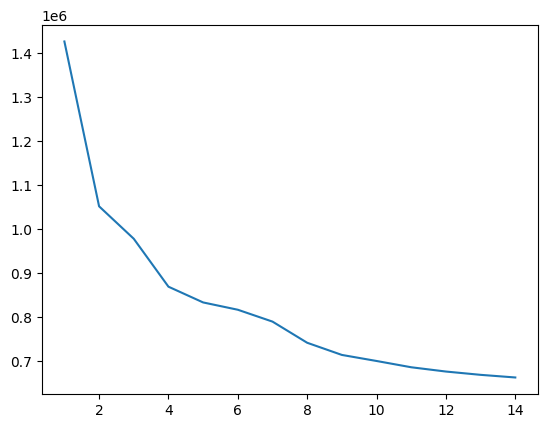

In [151]:
from sklearn.cluster import KMeans
inertia = []
for k in range(1, 15):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

import matplotlib.pyplot as plt
plt.plot(range(1, 15), inertia)
plt.show()

### kmeans

In [156]:
from sklearn.cluster import KMeans
k = 4 
kmeans = KMeans(n_clusters=k, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

### Creación de una columna con el cluster correspondiente al pais 

In [157]:
df_new[f'{columna}_cluster'] = clusters
nat_to_cluster = dict(zip(df_new[columna], df_new[f'{columna}_cluster']))


### Visualización de clusters

In [158]:
df_new[[columna, f'{columna}_cluster']].sort_values(f'{columna}_cluster')

,Club,Club_cluster
4425,Gol Gohar,0
3717,FC Fredericia,0
10968,Tromsø,0
3714,FC Fleury 91,0
9584,Salt,0
...,...,...
2307,Celaya III,3
9551,Saint George,3
2294,Cazalegas,3
7109,Molino Viejo,3


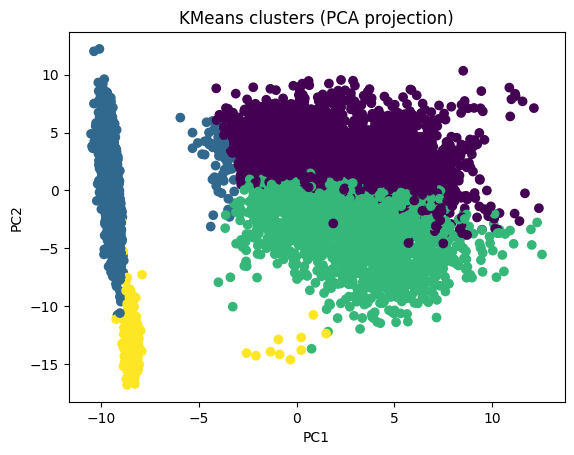

In [159]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure()
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters)

# # Optional: label each point (nationality)
# for i, nat in enumerate(df_nat['Nat']):
#     plt.text(X_pca[i, 0], X_pca[i, 1], nat, fontsize=8)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('KMeans clusters (PCA projection)')
plt.show()

# Creación de feature y asignación de cluster a cada jugador en el dataset

In [162]:
new_to_cluster = dict(zip(df_new[columna], df_new[f'{columna}_cluster']))
df[f'{columna}_cluster'] = df[columna].map(new_to_cluster)

In [163]:
print(df.columns) 

Index(['Nat', 'Division', 'Club', 'Based', 'Preferred Foot', 'Right Foot',
       'Left Foot', 'Position', 'Height', 'Weight', 'Age', 'Wage', 'AT Apps',
       'AT Gls', 'Team', 'Caps', 'Yth Apps', 'Style', 'Rc Injury', 'Best Role',
       'Best Duty', 'Best Pos', 'Acc', 'Aer', 'Agg', 'Agi', 'Ant', 'Bal',
       'Bra', 'Cmd', 'Com', 'Cmp', 'Cnt', 'Cor', 'Cro', 'Dec', 'Det', 'Dri',
       'Ecc', 'Fin', 'Fir', 'Fla', 'Fre', 'Han', 'Hea', 'Jum', 'Kic', 'Ldr',
       'Lon', 'L Th', 'Mar', 'Nat .1', 'OtB', '1v1', 'Pac', 'Pas', 'Pen',
       'Pos', 'Pun', 'Ref', 'TRO', 'Sta', 'Str', 'Tck', 'Tea', 'Tec', 'Thr',
       'Vis', 'Wor', 'transfer_value_estimado', 'Nat_cluster',
       'Division_cluster', 'Club_cluster'],
      dtype='object')


# Almcanenamiento del dataframe con las nuevas features 

In [164]:
df.to_pickle(f"datasets_pkl/{archivo}_post_kmeans.pkl")